In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
import matplotlib.pyplot as plt;

In [8]:
import numpy as np
import yfinance as yf
from scipy.stats import norm

# 1. Fetch Data
ticker = "RELIANCE.NS"
data = yf.download(ticker, period="1y", interval="1d")
S = data['Close'].iloc[-1].item()  # Latest price

# 2. Calculate Volatility
log_returns = np.log(data['Close'] / data['Close'].shift(1))
sigma = (log_returns.std() * np.sqrt(252)).item()

# 3. Inputs
K = 3000           # Strike Price
T = 1              # Time to Expiration (1 year)
r = 0.07           # Risk-free rate (7%)

# 4. Black-Scholes Formula
d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

call_price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
put_price = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * norm.cdf(-d1))

# 5. Show Results
print(f"--- Results for {ticker} ---")
print(f"Current Price: {S:.2f}")
print(f"Annual Volatility: {sigma:.2%}")
print(f"Call Option Price: {call_price:.2f}")
print(f"Put Option Price: {put_price:.2f}")

[*********************100%***********************]  1 of 1 completed

--- Results for RELIANCE.NS ---
Current Price: 1347.80
Annual Volatility: 20.46%
Call Option Price: 0.02
Put Option Price: 1449.40


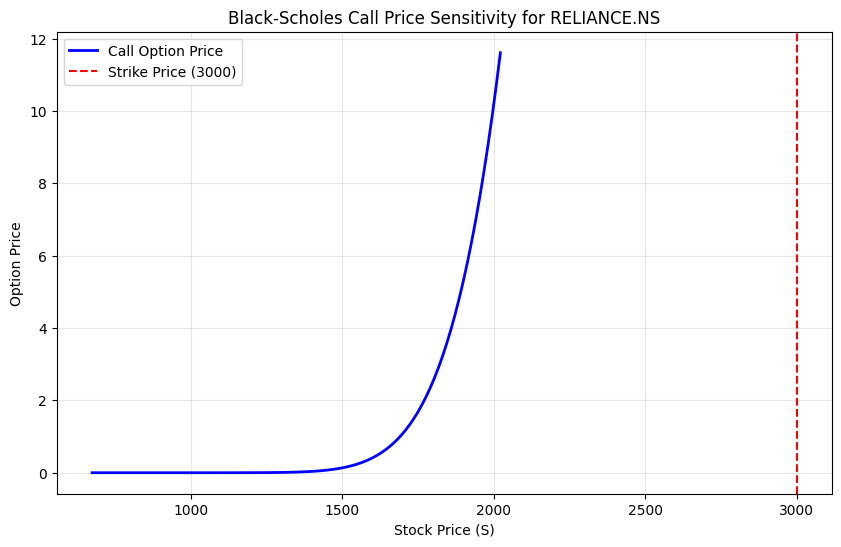

In [9]:
import matplotlib.pyplot as plt

# 1. Create a range of possible stock prices (from 50% to 150% of current price)
s_range = np.linspace(S * 0.5, S * 1.5, 100)

# 2. Calculate Call Price for every price in that range
calls = []
for price in s_range:
    d1_temp = (np.log(price / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_temp = d1_temp - sigma * np.sqrt(T)
    c_temp = (price * norm.cdf(d1_temp)) - (K * np.exp(-r * T) * norm.cdf(d2_temp))
    calls.append(c_temp)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(s_range, calls, color='blue', lw=2, label='Call Option Price')
plt.axvline(K, color='red', linestyle='--', label=f'Strike Price ({K})')
plt.title(f'Black-Scholes Call Price Sensitivity for {ticker}')
plt.xlabel('Stock Price (S)')
plt.ylabel('Option Price')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()